In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_CCI = pd.read_csv('CCI.csv')
# df_CCI = df_CCI[['REF_AREA', 'UNIT_MEASURE', 'TIME_PERIOD', 'OBS_VALUE']]
# df_CCI["YEAR"] = df_CCI["TIME_PERIOD"].str[:4].astype(int)
# df_CCI["MONTH"] = df_CCI["TIME_PERIOD"].str[5:7].astype(int)
# df_can = df_CCI[df_CCI["REF_AREA"] == "US"].copy()
# df_can["REF_AREA"] = "CAN"
# df_CCI = pd.concat([df_CCI, df_can], ignore_index=True)
# df_CCI["REF_AREA"] = df_CCI["REF_AREA"].replace({
#     "AUS": "AU",
#     "CAN": "CA",
#     "GBR": "GB",
#     "NZL": "NZ",
#     "USA": "US"})
# df_CCI = df_CCI[df_CCI["YEAR"] >= 2008]
# df_CCI.sort_values(["REF_AREA", "TIME_PERIOD"], inplace=True)
# df_CCI.reset_index(drop=True, inplace=True)
# df_CCI.to_csv('CCI_.csv', index=False)

In [3]:
df = pd.read_csv('dataset_update.csv')

# df["launched_at-year"] = pd.to_datetime(df["launched_at"]).dt.year
# df["launched_at-month"] = pd.to_datetime(df["launched_at"]).dt.month
# df = df.rename(columns={"usd_pledged": "pledged_usd"})
# df_merge = pd.merge(
#     df, 
#     df_CCI[['REF_AREA', 'YEAR', 'MONTH', 'OBS_VALUE']], 
#     left_on=['country', 'launched_at-year', 'launched_at-month'], 
#     right_on=['REF_AREA', 'YEAR', 'MONTH'], 
#     how='left'
# )
# df_merge = df_merge.rename(columns={'OBS_VALUE': 'CCI_index'})
# df_merge = df_merge.drop(columns=['REF_AREA', 'YEAR', 'MONTH'])
# df_merge.to_csv('dataset_update.csv', index=False)

In [4]:
df.head(3)

,id,name,blurb,state,launched_at,deadline,duration,country,category.parent_name,category.name,goal_usd,pledged_usd,backers_count,launched_at-year,launched_at-month,CCI_index
0,1432554512,Help get Das Good seasonings and sauces to sup...,Das Good Inc goal is to make cooking easy and ...,failed,2018-12-05 23:26:21,2019-02-03 23:26:21,60,US,Food,Restaurants,75000.0,266.0,6,2018,12,101.2287
1,1925377347,"""The Applicant: Interviews Are Hell""",A web series about the soul crushing exercise ...,failed,2016-12-26 13:45:21,2017-01-25 13:45:21,30,US,Film & Video,Webseries,6000.0,260.0,2,2016,12,101.2478
2,1876427386,5 Reasons to Hate Christmas,A romantic comedy mini series following a self...,failed,2018-04-10 18:33:16,2018-05-10 18:33:16,30,US,Film & Video,Webseries,10000.0,35.0,2,2018,4,101.5817


In [5]:
df.columns

Index(['id', 'name', 'blurb', 'state', 'launched_at', 'deadline', 'duration',
       'country', 'category.parent_name', 'category.name', 'goal_usd',
       'pledged_usd', 'backers_count', 'launched_at-year', 'launched_at-month',
       'CCI_index'],
      dtype='object')

In [6]:
len(df)

110161

<Axes: >

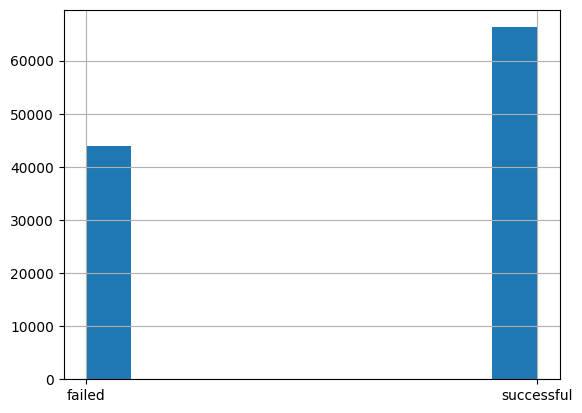

In [7]:
df["state"].hist()

<Axes: >

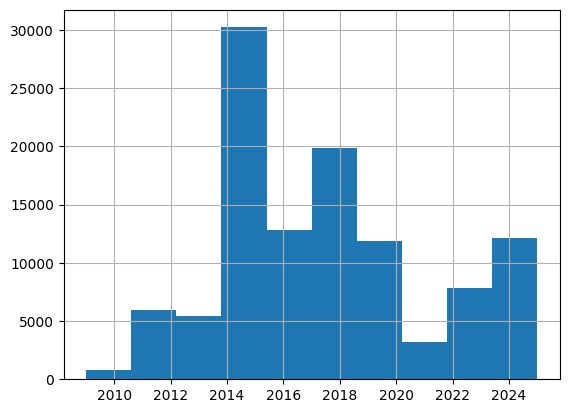

In [8]:
df["launched_at-year"].hist()

<Axes: >

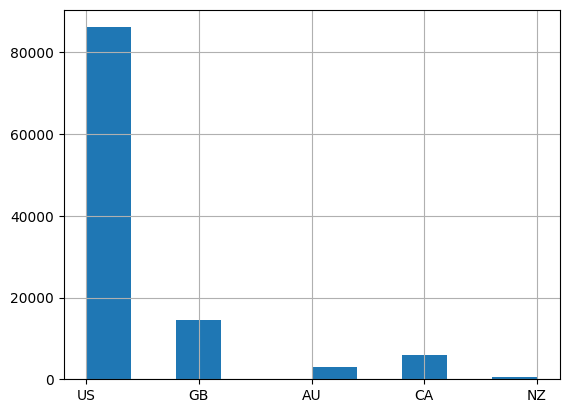

In [9]:
df["country"].hist()

<Axes: >

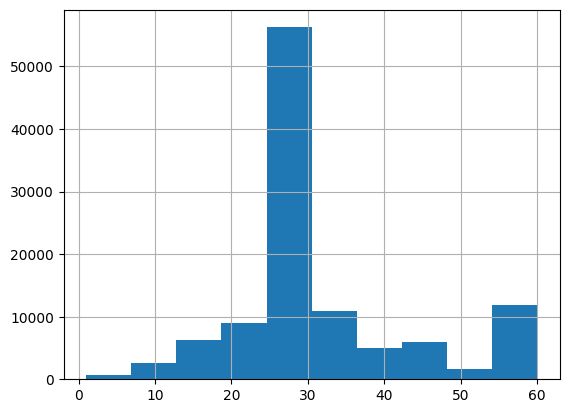

In [10]:
df["duration"].hist()

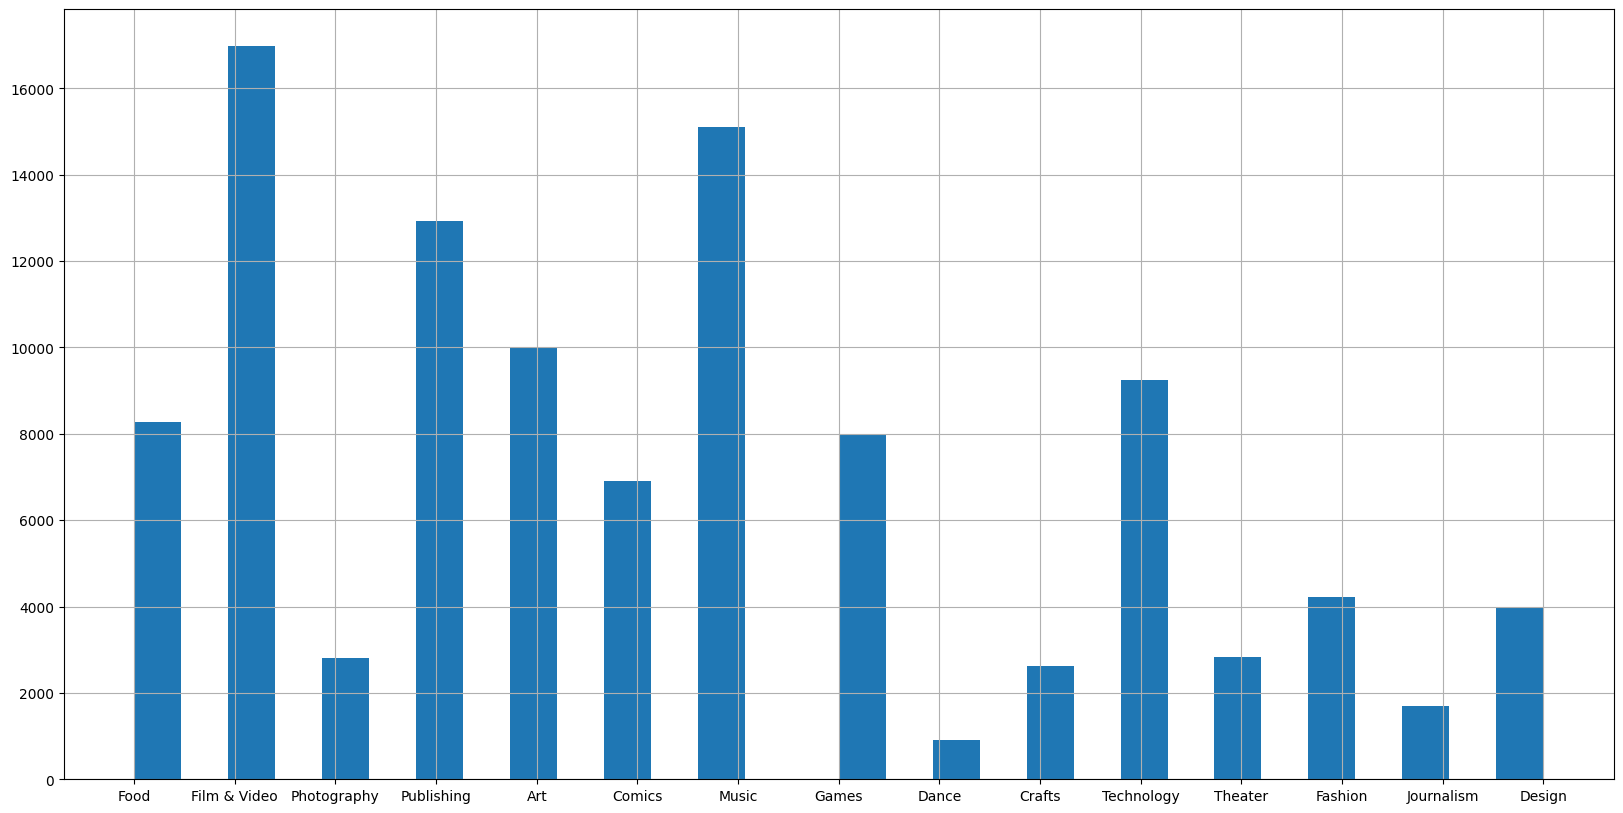

In [11]:
# Separated bins
plt.figure(figsize=(20, 10))
df["category.parent_name"].hist(bins=30)
plt.show()

<Axes: >

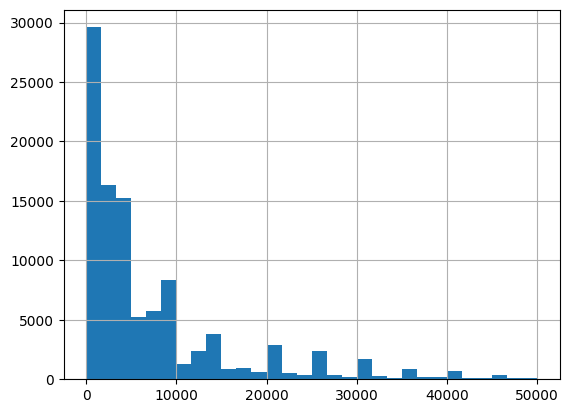

In [12]:
df[df["goal_usd"] < 50000]["goal_usd"].hist(bins=30)

<Axes: >

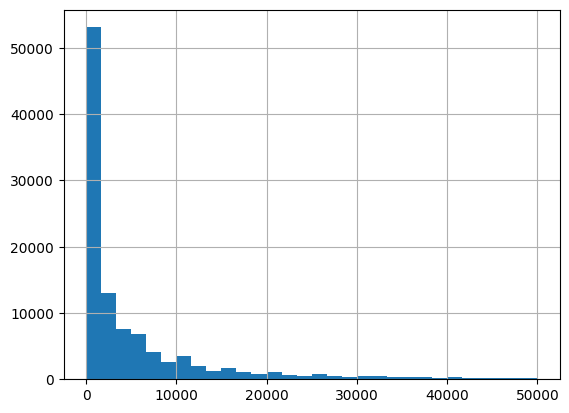

In [13]:
df[df["pledged_usd"] < 50000]["pledged_usd"].hist(bins=30)

In [14]:
len(df[df["backers_count"] == 0])

7621

<Axes: >

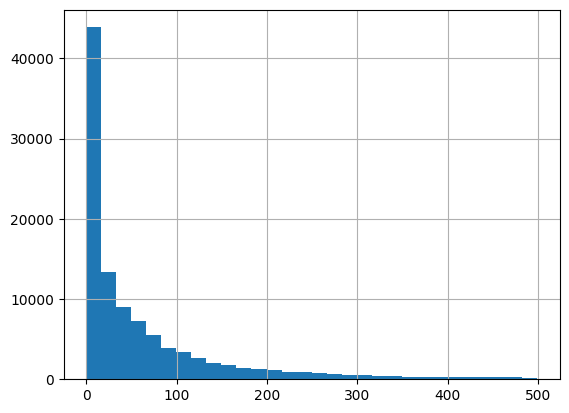

In [15]:
df[df["backers_count"] < 500]["backers_count"].hist(bins=30)

In [16]:
import plotly.express as px

areas = df_CCI["REF_AREA"].unique()
fig = px.line()
for area in areas:
    area_data = df_CCI[df_CCI["REF_AREA"] == area]
    fig.add_scatter(x=area_data["TIME_PERIOD"], y=area_data["OBS_VALUE"], mode="lines", name=area)
fig.update_xaxes(title_text="Year")
fig.update_yaxes(title_text="CCI")
fig.update_layout(title="Consumer Confidence Index by Area")